# Exploratory Data Analysis (EDA)

This notebook now prioritizes `merged_data.csv` and performs a broader profile of source coverage, data quality, temporal behavior, text characteristics, and engagement signals.


In [10]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from collections import Counter
import re

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10

STOPWORDS = {
    'the', 'a', 'an', 'and', 'or', 'to', 'of', 'in', 'on', 'for', 'is', 'are',
    'at', 'it', 'this', 'that', 'with', 'as', 'be', 'by', 'from', 'i', 'you',
    'your', 'my', 'we', 'our', 'they', 'he', 'she', 'them', 'me', 'us',
    'na', 'ng', 'sa', 'ang', 'mga', 'si', 'ako', 'ko', 'mo', 'ka', 'ni', 'nang',
    'yung', 'yan', 'ito', 'iyon', 'din', 'rin', 'lang', 'talaga', 'kasi', 'pero'
}


def extract_tokens(series):
    tokens = []
    for value in series.fillna('').astype(str):
        words = re.findall(r"[a-zA-Z']{3,}", value.lower())
        tokens.extend([word for word in words if word not in STOPWORDS])
    return tokens


def top_tokens(series, n=15):
    return pd.DataFrame(Counter(extract_tokens(series)).most_common(n), columns=['token', 'count'])


In [11]:
candidate_paths = [
    Path('../data/processed/merged_data.csv'),
    Path('../data/processed/merged_data_2.csv')
]

DATA_PATH = next((p for p in candidate_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(f'None of the expected datasets exist: {candidate_paths}')

df = pd.read_csv(DATA_PATH)

for col in ['created_at', 'date_posted', 'date', 'updated_at', 'date_collected']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce', utc=True)

for col in ['view_count', 'like_count', 'share_count', 'comment_count']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

if 'source' in df.columns:
    df['source'] = df['source'].fillna('unknown').astype(str).str.strip().str.lower()

if 'language' in df.columns:
    df['language'] = df['language'].fillna('unknown').astype(str).str.strip().str.lower()

if 'text' in df.columns:
    df['text'] = df['text'].fillna('').astype(str)

if 'cleaned_text' in df.columns:
    df['cleaned_text'] = df['cleaned_text'].fillna('').astype(str)
elif 'text' in df.columns:
    df['cleaned_text'] = df['text']

date_candidates = ['created_at', 'date_posted', 'date']
analysis_date_col = next((col for col in date_candidates if col in df.columns and df[col].notna().any()), None)
df['analysis_date'] = df[analysis_date_col] if analysis_date_col else pd.NaT

if 'text' in df.columns:
    df['char_len'] = df['text'].str.len()
    df['word_len'] = df['text'].str.split().str.len()
    df['is_empty_text'] = df['text'].str.strip().eq('')

metric_cols = [col for col in ['view_count', 'like_count', 'share_count', 'comment_count'] if col in df.columns]
if metric_cols:
    df['engagement_total'] = df[metric_cols].fillna(0).sum(axis=1)

preview_cols = [col for col in ['source', 'language', 'analysis_date', 'text'] if col in df.columns]
if metric_cols:
    preview_cols += metric_cols[:2]

print(f'Loaded: {DATA_PATH}')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Primary analysis date column: {analysis_date_col or "None"}')
print(f'Available metric columns: {metric_cols if metric_cols else "None"}')

display(df[preview_cols].head() if preview_cols else df.head())


Loaded: ../data/processed/merged_data.csv
Shape: 10,857 rows x 19 columns
Primary analysis date column: created_at
Available metric columns: ['view_count', 'like_count', 'share_count', 'comment_count']


,source,language,analysis_date,text,view_count,like_count
0,twitter,ja,2025-09-21 23:59:43+00:00,https://t.co/jbO5TDH1nM 牛乳石鹸コラボユニボールワンP 1家族1...,NaN,NaN
1,twitter,tl,2025-09-21 23:53:27+00:00,anong gusto mo gawin niya makipagbarda sa mga ...,NaN,NaN
2,twitter,sh,2025-09-21 23:28:01+00:00,grabe na hutoy sa ubo thanks mama cels sa pag ...,NaN,NaN
3,twitter,es,2025-09-21 23:26:11+00:00,@ubo_ub @MaseDenver Trautman sucks ass,NaN,NaN
4,twitter,en,2025-09-21 23:19:27+00:00,@MaseDenver @MaseDenver thoughts on the offici...,NaN,NaN


## 1) Structure and Coverage


In [12]:
schema_profile = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'non_null_count': df.notna().sum(),
    'null_count': df.isna().sum(),
    'null_pct': (df.isna().mean() * 100).round(2),
    'unique_count': df.nunique(dropna=True)
}).sort_values(['null_pct', 'unique_count'], ascending=[False, False])

display(schema_profile)

dataset_summary = {
    'rows': len(df),
    'columns': df.shape[1],
    'source_count': int(df['source'].nunique()) if 'source' in df.columns else 0,
    'language_count': int(df['language'].nunique()) if 'language' in df.columns else 0,
    'date_column_used': analysis_date_col or 'None',
    'valid_dates': int(df['analysis_date'].notna().sum()) if 'analysis_date' in df.columns else 0,
    'date_min': df['analysis_date'].min() if 'analysis_date' in df.columns and df['analysis_date'].notna().any() else pd.NaT,
    'date_max': df['analysis_date'].max() if 'analysis_date' in df.columns and df['analysis_date'].notna().any() else pd.NaT,
}

display(pd.Series(dataset_summary, name='value').to_frame())

if 'source' in df.columns:
    source_mix = df['source'].value_counts(dropna=False).rename_axis('source').to_frame('count')
    source_mix['pct'] = (source_mix['count'] / len(df) * 100).round(2)
    display(source_mix)


,dtype,non_null_count,null_count,null_pct,unique_count
comment_count,float64,1226,9631,88.71,248
share_count,float64,1725,9132,84.11,390
view_count,float64,2108,8749,80.58,817
like_count,float64,5848,5009,46.14,1198
id,str,10857,0,0.00,10857
external_post_id,str,10857,0,0.00,10857
text,str,10857,0,0.00,10682
date_posted,"datetime64[us, UTC]",10857,0,0.00,10491
created_at,"datetime64[us, UTC]",10857,0,0.00,10491
analysis_date,"datetime64[us, UTC]",10857,0,0.00,10491


,value
rows,10857
columns,19
source_count,5
language_count,82
date_column_used,created_at
valid_dates,10857
date_min,2009-02-10 12:00:12+00:00
date_max,2026-03-11 09:50:55+00:00


,count,pct
source,,
reddit,3877,35.71
threads,3635,33.48
twitter,2539,23.39
tiktok,726,6.69
facebook,80,0.74


## 2) Data Quality and Missingness


,count
exact_duplicate_rows,0
duplicate_id_rows,0
duplicate_text_rows,175
duplicate_source_external_post_id,0
empty_text_rows,0
short_text_rows_lt_5_words,804


,missing_count,missing_pct
comment_count,9631,88.71
share_count,9132,84.11
view_count,8749,80.58
like_count,5009,46.14
is_empty_text,0,0.00
word_len,0,0.00
char_len,0,0.00
analysis_date,0,0.00
updated_at,0,0.00
created_at,0,0.00


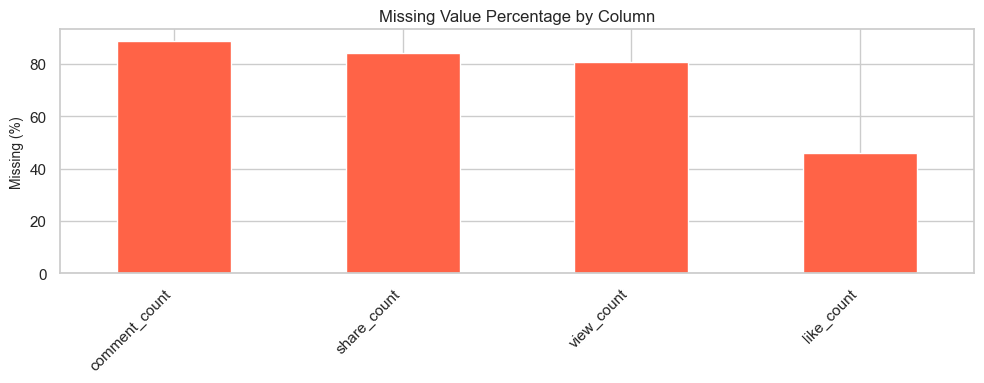

,text,cleaned_text,language,analysis_date,view_count,like_count,share_count,comment_count
source,,,,,,,,
facebook,100.0,100.0,100.0,100.0,0.0,100.0,0.0,0.0
reddit,100.0,100.0,100.0,100.0,0.0,100.0,0.0,0.0
threads,100.0,100.0,100.0,100.0,24.5,38.3,13.7,0.0
tiktok,100.0,100.0,100.0,100.0,100.0,0.0,100.0,100.0
twitter,100.0,100.0,100.0,100.0,19.3,19.7,19.7,19.7


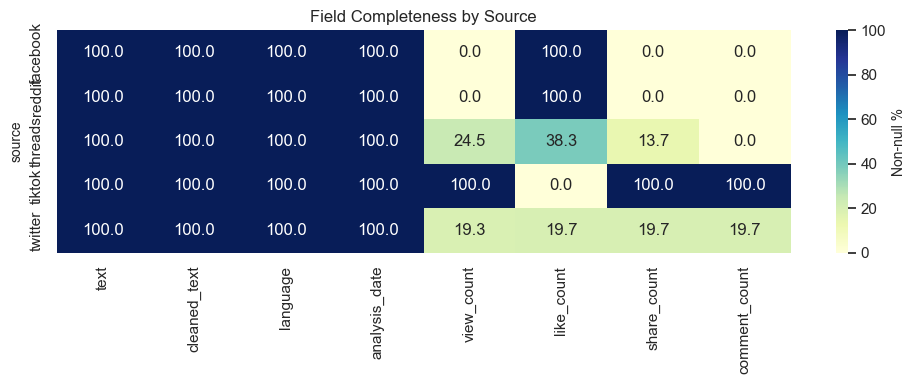

In [13]:
quality_checks = {
    'exact_duplicate_rows': int(df.duplicated().sum()),
    'duplicate_id_rows': int(df.duplicated(subset=['id']).sum()) if 'id' in df.columns else np.nan,
    'duplicate_text_rows': int(df.duplicated(subset=['text']).sum()) if 'text' in df.columns else np.nan,
    'duplicate_source_external_post_id': int(df.duplicated(subset=['source', 'external_post_id']).sum()) if {'source', 'external_post_id'}.issubset(df.columns) else np.nan,
    'empty_text_rows': int(df['is_empty_text'].sum()) if 'is_empty_text' in df.columns else np.nan,
    'short_text_rows_lt_5_words': int((df['word_len'] < 5).sum()) if 'word_len' in df.columns else np.nan,
}

display(pd.Series(quality_checks, name='count').to_frame())

missing_df = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2)
}).sort_values('missing_pct', ascending=False)

display(missing_df)

if (missing_df['missing_count'] > 0).any():
    plt.figure(figsize=(10, 4))
    missing_df[missing_df['missing_count'] > 0]['missing_pct'].plot(kind='bar', color='tomato')
    plt.title('Missing Value Percentage by Column')
    plt.ylabel('Missing (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

completeness_cols = [col for col in ['text', 'cleaned_text', 'language', 'analysis_date'] + metric_cols if col in df.columns]
if 'source' in df.columns and completeness_cols:
    completeness_by_source = (df.groupby('source')[completeness_cols].apply(lambda x: x.notna().mean() * 100)).round(1)
    display(completeness_by_source)

    plt.figure(figsize=(10, 4))
    sns.heatmap(completeness_by_source, annot=True, fmt='.1f', cmap='YlGnBu', cbar_kws={'label': 'Non-null %'})
    plt.title('Field Completeness by Source')
    plt.tight_layout()
    plt.show()


## 3) Source, Language, and Platform Mix


,count
source,
reddit,3877
threads,3635
twitter,2539
tiktok,726
facebook,80


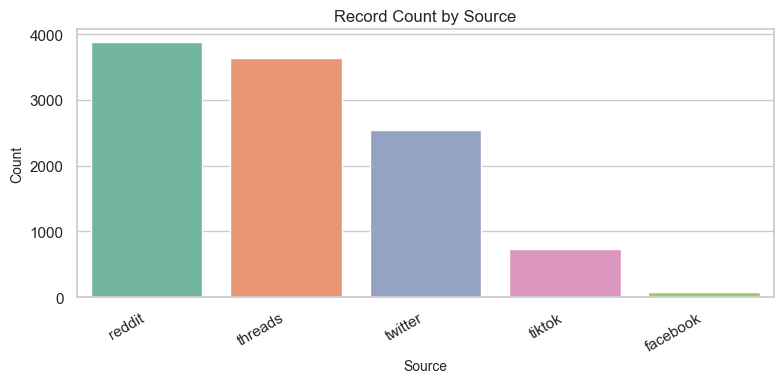

,count
language,
en,4941
tl,4223
id,475
ceb,306
ja,106
es,98
ms,67
it,64
war,60


language,en,tl,id,ceb,ja,es,ms,it,war,de
source,,,,,,,,,,
facebook,9,63,4,0,0,0,0,0,1,1
reddit,1944,1741,6,47,9,17,2,11,2,8
threads,2092,1053,58,201,13,23,20,31,12,17
tiktok,341,173,28,27,12,23,1,13,7,3
twitter,555,1193,379,31,72,35,44,9,38,22


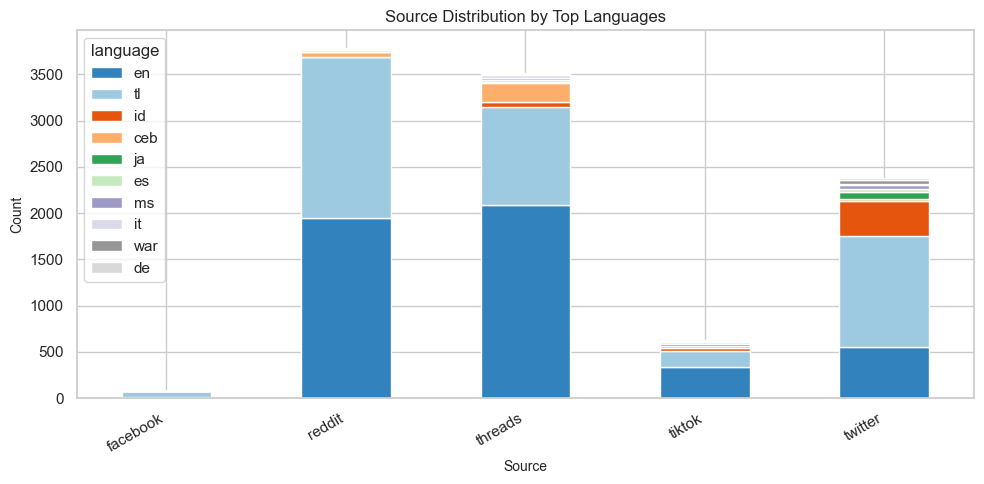

,view_count,like_count,share_count,comment_count
source,,,,
facebook,0.0,100.0,0.0,0.0
reddit,0.0,100.0,0.0,0.0
threads,24.5,38.3,13.7,0.0
tiktok,100.0,0.0,100.0,100.0
twitter,19.3,19.7,19.7,19.7


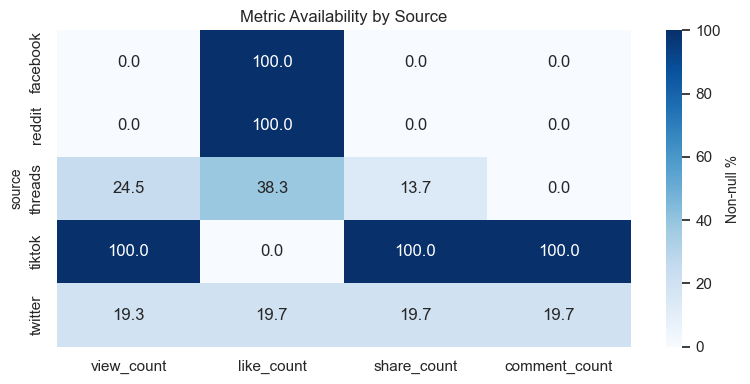

In [14]:
if 'source' not in df.columns:
    print('No source column found.')
else:
    source_counts = df['source'].value_counts().sort_values(ascending=False)
    display(source_counts.to_frame('count'))

    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x='source', order=source_counts.index, palette='Set2')
    plt.title('Record Count by Source')
    plt.xlabel('Source')
    plt.ylabel('Count')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

    if 'language' in df.columns:
        language_counts = df['language'].value_counts().head(10)
        display(language_counts.to_frame('count'))

        source_language = pd.crosstab(df['source'], df['language'])
        top_languages = language_counts.index.tolist()
        source_language = source_language.loc[:, [lang for lang in top_languages if lang in source_language.columns]]
        display(source_language)

        if not source_language.empty:
            source_language.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='tab20c')
            plt.title('Source Distribution by Top Languages')
            plt.xlabel('Source')
            plt.ylabel('Count')
            plt.xticks(rotation=30, ha='right')
            plt.tight_layout()
            plt.show()

    if metric_cols:
        metric_presence = (df.groupby('source')[metric_cols].apply(lambda x: x.notna().mean() * 100)).round(1)
        display(metric_presence)

        plt.figure(figsize=(8, 4))
        sns.heatmap(metric_presence, annot=True, fmt='.1f', cmap='Blues', cbar_kws={'label': 'Non-null %'})
        plt.title('Metric Availability by Source')
        plt.tight_layout()
        plt.show()


## 4) Temporal Patterns


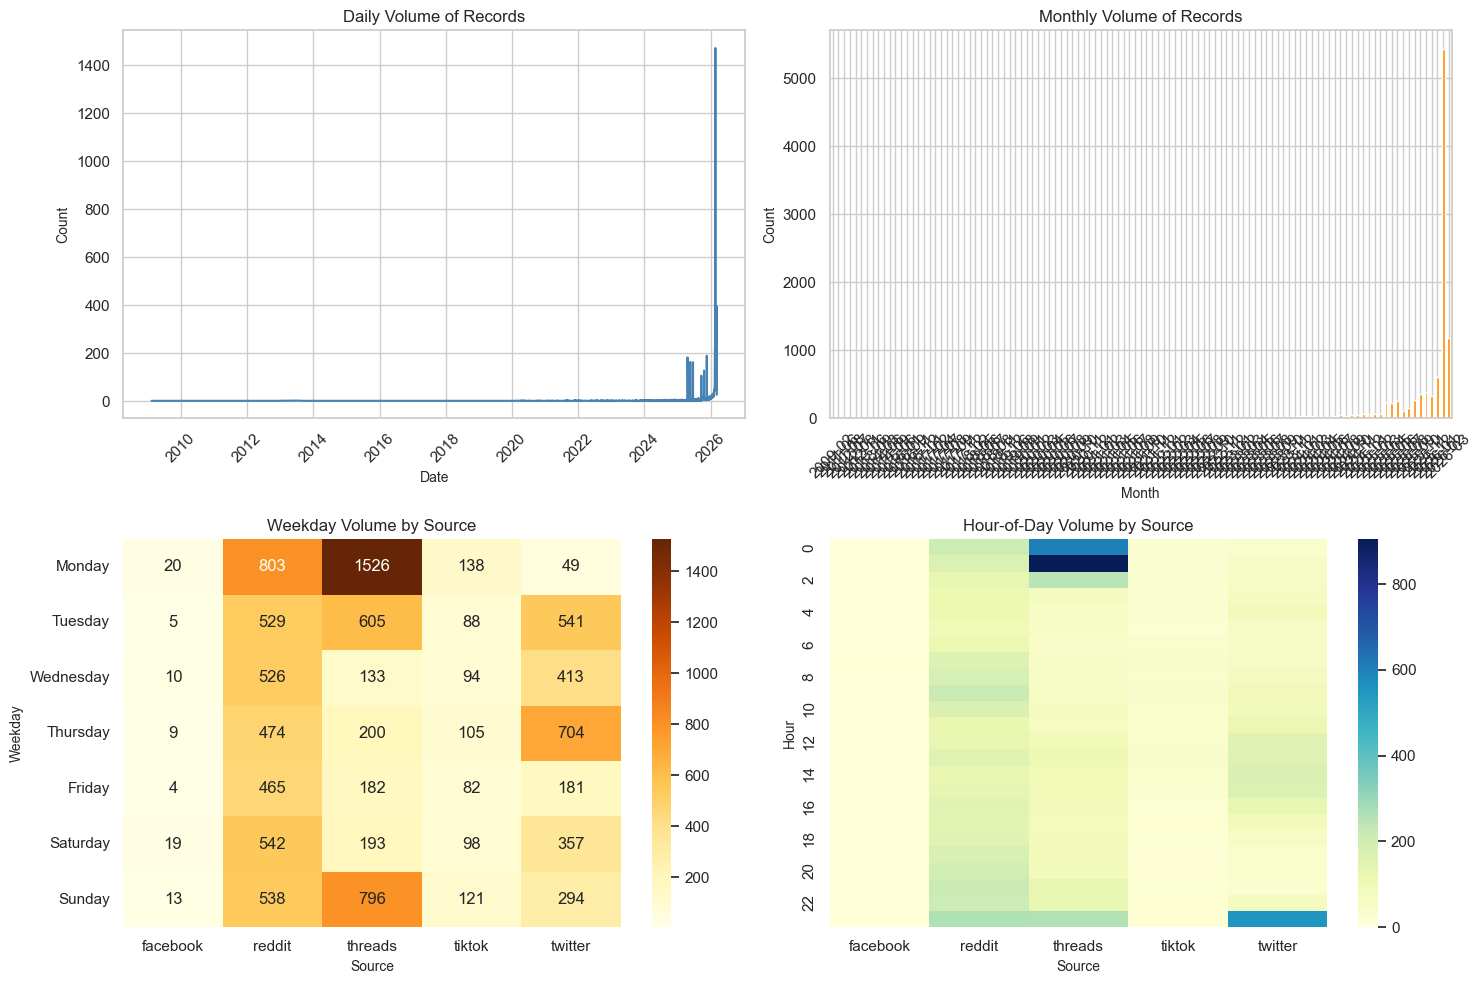

source,facebook,reddit,threads,tiktok,twitter
date_only,,,,,
2026-03-02,0,22,49,11,0
2026-03-03,0,10,29,8,0
2026-03-04,0,16,31,12,0
2026-03-05,0,12,84,9,0
2026-03-06,0,19,15,13,0
2026-03-07,0,75,8,10,0
2026-03-08,0,90,65,37,0
2026-03-09,0,346,6,43,0
2026-03-10,0,42,0,6,0


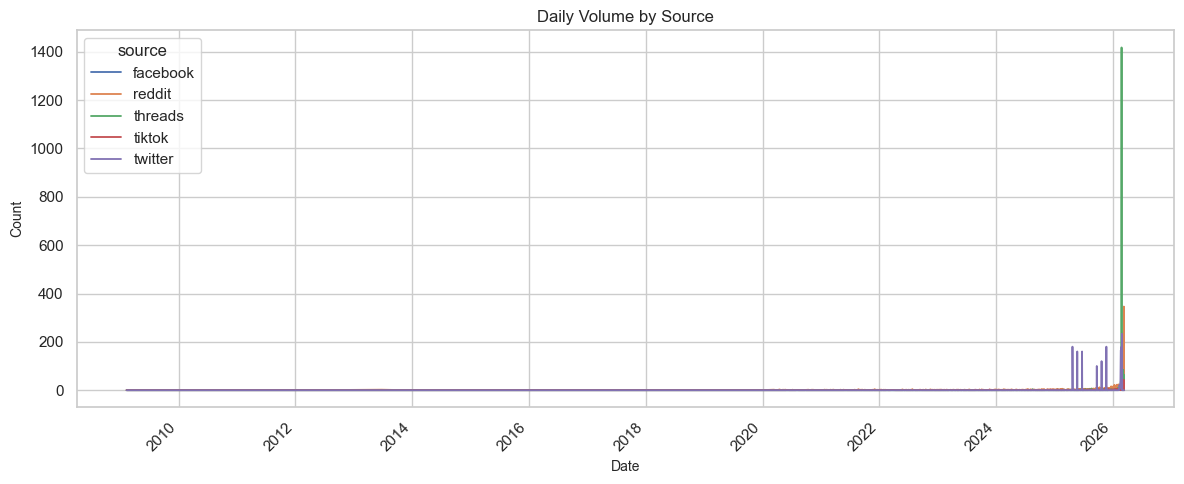

In [15]:
if analysis_date_col is None or df['analysis_date'].isna().all():
    print('No usable datetime column found for temporal analysis.')
else:
    ts = df.dropna(subset=['analysis_date']).copy()
    ts['date_only'] = ts['analysis_date'].dt.date
    ts['month'] = ts['analysis_date'].dt.to_period('M').astype(str)
    ts['weekday'] = pd.Categorical(
        ts['analysis_date'].dt.day_name(),
        categories=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
        ordered=True,
    )
    ts['hour'] = ts['analysis_date'].dt.hour

    daily_counts = ts.groupby('date_only').size()
    monthly_counts = ts.groupby('month').size()

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    daily_counts.plot(ax=axes[0, 0], linewidth=1.5, color='steelblue')
    axes[0, 0].set_title('Daily Volume of Records')
    axes[0, 0].set_xlabel('Date')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].tick_params(axis='x', rotation=45)

    monthly_counts.plot(kind='bar', ax=axes[0, 1], color='darkorange')
    axes[0, 1].set_title('Monthly Volume of Records')
    axes[0, 1].set_xlabel('Month')
    axes[0, 1].set_ylabel('Count')
    axes[0, 1].tick_params(axis='x', rotation=45)

    weekday_source = pd.crosstab(ts['weekday'], ts['source']) if 'source' in ts.columns else pd.crosstab(ts['weekday'], columns='count')
    sns.heatmap(weekday_source, annot=True, fmt='g', cmap='YlOrBr', ax=axes[1, 0])
    axes[1, 0].set_title('Weekday Volume by Source')
    axes[1, 0].set_xlabel('Source')
    axes[1, 0].set_ylabel('Weekday')

    hour_source = pd.crosstab(ts['hour'], ts['source']) if 'source' in ts.columns else pd.crosstab(ts['hour'], columns='count')
    sns.heatmap(hour_source, cmap='YlGnBu', ax=axes[1, 1])
    axes[1, 1].set_title('Hour-of-Day Volume by Source')
    axes[1, 1].set_xlabel('Source')
    axes[1, 1].set_ylabel('Hour')

    plt.tight_layout()
    plt.show()

    if 'source' in ts.columns:
        daily_by_source = ts.pivot_table(index='date_only', columns='source', aggfunc='size', fill_value=0)
        display(daily_by_source.tail(10))

        daily_by_source.plot(figsize=(12, 5), linewidth=1.3)
        plt.title('Daily Volume by Source')
        plt.xlabel('Date')
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()


## 5) Text Analysis


,count,mean,std,min,50%,75%,90%,95%,99%,max
char_len,10857.0,521.05,1640.67,1.0,141.0,381.0,1154.0,2117.2,6045.6,39518.0
word_len,10857.0,89.49,270.06,1.0,24.0,67.0,202.0,373.0,1021.0,7154.0


char_len                       word_len                    
            count median    mean    max    count median   mean   max
source                                                              
facebook       80  120.5   420.9   6144       80   20.0   72.2  1021
reddit       3877  482.0  1189.5  39518     3877   85.0  204.7  7154
threads      3635  141.0   188.4   1445     3635   24.0   32.7   240
tiktok        726   69.0   121.9   4035      726    9.0   17.2   656
twitter      2539   68.0    93.8   1163     2539   12.0   16.1   192

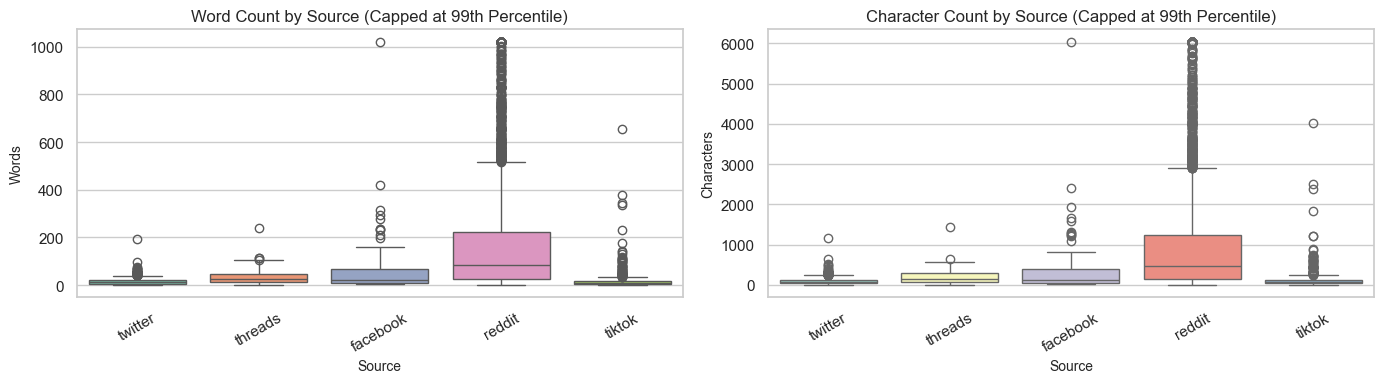

,token,count
0,may,6120
1,hindi,5575
2,naman,3737
3,siya,3134
4,nya,3075
5,para,2989
6,niya,2954
7,kung,2931
8,wala,2703
9,nag,2619


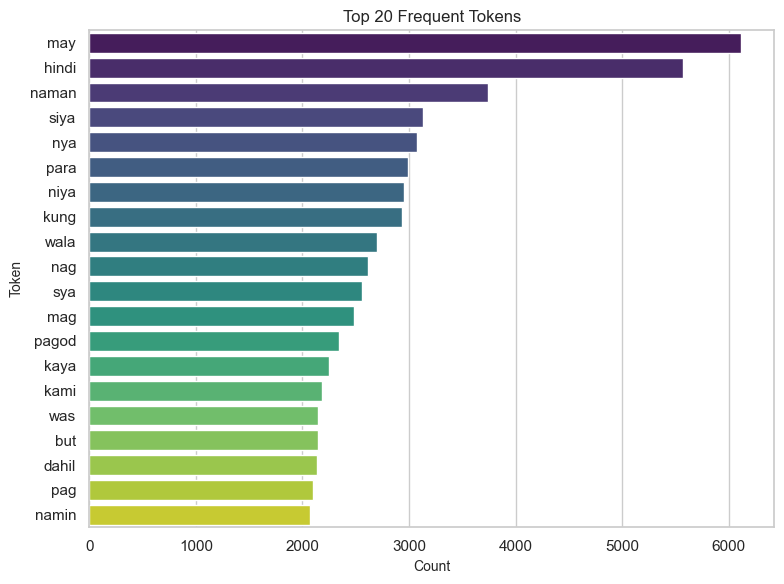

,source,token,count
0,facebook,lagnat,126
1,facebook,may,92
2,facebook,kung,49
3,facebook,pag,48
4,facebook,hindi,43
5,facebook,para,37
6,facebook,bata,35
7,facebook,siya,34
8,facebook,baby,30
9,facebook,gamot,30


In [16]:
if 'text' not in df.columns:
    print('No text column found.')
else:
    text_summary = df[['char_len', 'word_len']].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).transpose().round(2)
    display(text_summary)

    if 'source' in df.columns:
        text_by_source = df.groupby('source')[['char_len', 'word_len']].agg(['count', 'median', 'mean', 'max']).round(1)
        display(text_by_source)

        plot_df = df.copy()
        plot_df['word_len_capped'] = plot_df['word_len'].clip(upper=plot_df['word_len'].quantile(0.99))
        plot_df['char_len_capped'] = plot_df['char_len'].clip(upper=plot_df['char_len'].quantile(0.99))

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        sns.boxplot(data=plot_df, x='source', y='word_len_capped', ax=axes[0], palette='Set2')
        axes[0].set_title('Word Count by Source (Capped at 99th Percentile)')
        axes[0].set_xlabel('Source')
        axes[0].set_ylabel('Words')
        axes[0].tick_params(axis='x', rotation=30)

        sns.boxplot(data=plot_df, x='source', y='char_len_capped', ax=axes[1], palette='Set3')
        axes[1].set_title('Character Count by Source (Capped at 99th Percentile)')
        axes[1].set_xlabel('Source')
        axes[1].set_ylabel('Characters')
        axes[1].tick_params(axis='x', rotation=30)

        plt.tight_layout()
        plt.show()

    token_source = df['cleaned_text'] if 'cleaned_text' in df.columns else df['text']
    top_tokens_overall = top_tokens(token_source, n=20)
    display(top_tokens_overall)

    if not top_tokens_overall.empty:
        plt.figure(figsize=(8, 6))
        sns.barplot(data=top_tokens_overall, x='count', y='token', palette='viridis')
        plt.title('Top 20 Frequent Tokens')
        plt.xlabel('Count')
        plt.ylabel('Token')
        plt.tight_layout()
        plt.show()

    if 'source' in df.columns:
        source_token_tables = []
        for source, group in df.groupby('source'):
            source_tokens = top_tokens(group['cleaned_text'] if 'cleaned_text' in group.columns else group['text'], n=10)
            source_tokens.insert(0, 'source', source)
            source_token_tables.append(source_tokens)

        if source_token_tables:
            display(pd.concat(source_token_tables, ignore_index=True))


## 6) Engagement Metrics and Correlation


,count,mean,std,min,50%,75%,90%,95%,99%,max
view_count,2108.0,174422.02,1228572.09,0.0,10.0,1451.25,112510.0,564185.00,3200000.00,28600000.0
like_count,5848.0,1787.47,8498.34,0.0,6.0,89.25,1878.5,6345.30,49221.18,144679.0
share_count,1725.0,1111.32,7752.60,0.0,1.0,39.00,761.2,3029.60,21856.00,184400.0
comment_count,1226.0,181.33,1038.07,0.0,1.0,28.00,217.0,655.25,4397.75,26600.0
engagement_total,10857.0,35025.71,546915.26,0.0,1.0,41.00,1972.2,18433.40,530293.96,28610069.0


,non_null_pct,zero_pct,max_value
view_count,19.42,88.79,28600000.0
like_count,53.86,57.18,144679.0
share_count,15.89,91.94,184400.0
comment_count,11.29,93.33,26600.0


view_count                                 like_count         \
              count   median       mean         max      count median   
source                                                                  
facebook          0      NaN        NaN         NaN         80   65.5   
reddit            0      NaN        NaN         NaN       3877   12.0   
threads         891      0.0       0.00         0.0       1391    1.0   
tiktok          726  20100.0  506132.80  28600000.0          0    NaN   
twitter         491     20.0     466.82     43102.0        500    0.0   

                            share_count                            \
             mean       max       count median     mean       max   
source                                                              
facebook  4893.19  100937.0           0    NaN      NaN       NaN   
reddit    2466.07  144679.0           0    NaN      NaN       NaN   
threads    357.31   44854.0         499    1.0    69.82    3373.0   
tiktok        NaN       NaN         726   26.5  2592.05  184400.0   
twitter      7.44     729.0         500    0.0     0.73     113.0   

         comment_count                         engagement_total           \
                 count median    mean      max            count   median   
source                                                                     
facebook             0    NaN     NaN      NaN               80     65.5   
reddit               0    NaN     NaN      NaN             3877     12.0   
threads              0    NaN     NaN      NaN             3635      0.0   
tiktok             726   17.0  306.01  26600.0              726  20206.0   
twitter            500    0.0    0.30     12.0             2539      0.0   

                                 
               mean         max  
source                           
facebook    4893.19    100937.0  
reddit      2466.07    144679.0  
threads      146.31     46464.0  
tiktok    509030.86  28610069.0  
twitter       91.94     43904.0

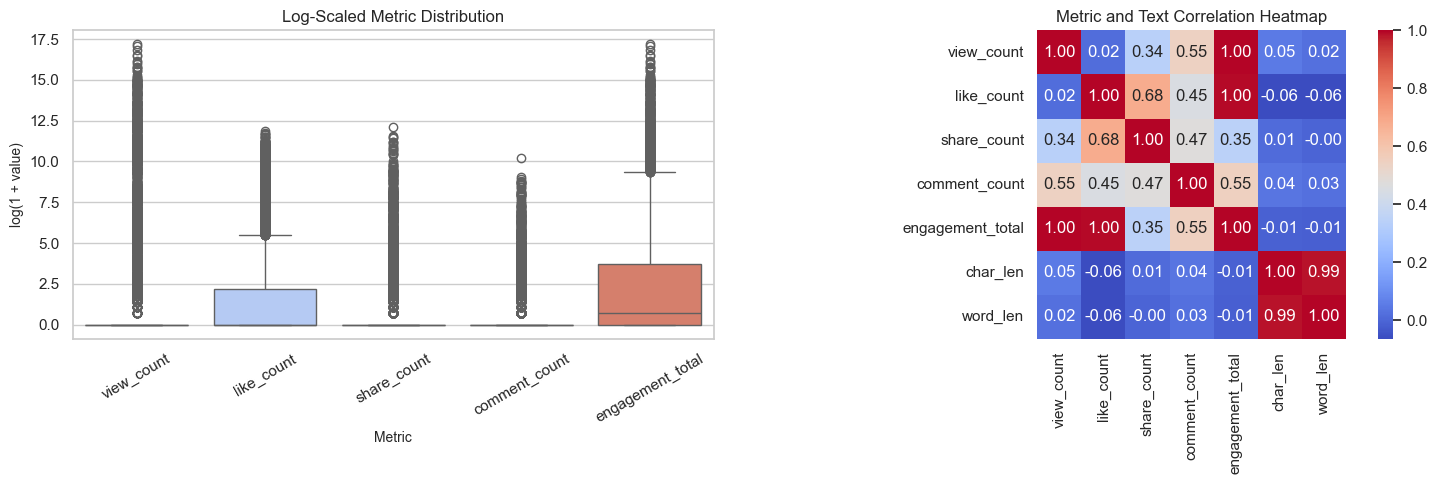

,source,language,analysis_date,engagement_total,view_count,like_count,share_count,comment_count,text
10577,tiktok,en,2022-02-13 09:19:13+00:00,28610069.0,28600000.0,NaN,3608.0,6461.0,The Good King and the Beggar's Spicy Food #틱톡푸...
10578,tiktok,en,2022-03-11 10:25:52+00:00,26511023.0,26500000.0,NaN,2443.0,8580.0,SPICY FIRE NOODLES SPAM MUKBANG EATING SOUNDS ...
10788,tiktok,en,2024-01-19 22:53:28+00:00,20126460.0,20100000.0,NaN,18800.0,7660.0,Follow and learn about why you would have air ...
10824,tiktok,tl,2024-09-20 04:30:10+00:00,15402870.0,15400000.0,NaN,2344.0,526.0,"Madaling pagkapagod, panghihina o bawas na gan..."
10259,tiktok,vi,2025-08-01 11:02:36+00:00,14277278.0,14200000.0,NaN,71100.0,6178.0,"""Người được gắn thẻ nợ bạn một điều"" #DarkNigh..."
10674,tiktok,tr,2025-05-31 12:12:30+00:00,10336163.0,10300000.0,NaN,33100.0,3063.0,"Barış Alper Yılmaz, 23 Mayıs 2000 tarihinde Ri..."
10805,tiktok,zh,2021-06-01 12:00:00+00:00,9601436.0,9600000.0,NaN,316.0,1120.0,Too embarrassing 😂 #iqiyi #fyp #myroomateisagu...
10636,tiktok,en,2022-08-10 13:22:46+00:00,8818618.0,8800000.0,NaN,14100.0,4518.0,Here’s my version of Beer by Itchyworms🍻 tara ...
10460,tiktok,tl,2024-11-21 00:30:00+00:00,7195132.0,7100000.0,NaN,92900.0,2232.0,Hindi raw dapat binabalewala ang pagkakaroon n...
10308,tiktok,en,2024-07-28 22:09:17+00:00,7009063.0,7000000.0,NaN,6402.0,2661.0,Sipping on pepsi @Álvarito🐍 @𝖆𝖕𝖔𝖑𝖔


In [17]:
if not metric_cols:
    print('No engagement metric columns found.')
else:
    metric_summary = df[metric_cols + ['engagement_total']].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).transpose().round(2)
    display(metric_summary)

    metric_health = pd.DataFrame({
        'non_null_pct': (df[metric_cols].notna().mean() * 100).round(2),
        'zero_pct': ((df[metric_cols].fillna(0) == 0).mean() * 100).round(2),
        'max_value': df[metric_cols].max()
    })
    display(metric_health)

    if 'source' in df.columns:
        metric_by_source = df.groupby('source')[metric_cols + ['engagement_total']].agg(['count', 'median', 'mean', 'max']).round(2)
        display(metric_by_source)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    log_metric_df = np.log1p(df[metric_cols + ['engagement_total']].fillna(0))
    sns.boxplot(data=log_metric_df.melt(var_name='metric', value_name='log_value'), x='metric', y='log_value', ax=axes[0], palette='coolwarm')
    axes[0].set_title('Log-Scaled Metric Distribution')
    axes[0].set_xlabel('Metric')
    axes[0].set_ylabel('log(1 + value)')
    axes[0].tick_params(axis='x', rotation=30)

    corr_cols = metric_cols + [col for col in ['engagement_total', 'char_len', 'word_len'] if col in df.columns]
    corr = df[corr_cols].corr(numeric_only=True)
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, ax=axes[1])
    axes[1].set_title('Metric and Text Correlation Heatmap')

    plt.tight_layout()
    plt.show()

    top_post_cols = [col for col in ['source', 'language', 'analysis_date', 'engagement_total'] + metric_cols + ['text'] if col in df.columns]
    display(df.nlargest(10, 'engagement_total')[top_post_cols])


## 7) Representative Records and Outliers


In [18]:
example_cols = [col for col in ['source', 'language', 'analysis_date', 'external_post_id', 'word_len', 'char_len', 'engagement_total', 'text'] if col in df.columns]

if 'word_len' in df.columns:
    print('Longest posts by word count')
    display(df.nlargest(10, 'word_len')[example_cols])

    print('Shortest non-empty posts')
    shortest_non_empty = df[df['word_len'] > 0].nsmallest(10, 'word_len')
    display(shortest_non_empty[example_cols])

if 'engagement_total' in df.columns:
    print('Highest-engagement posts')
    display(df.nlargest(10, 'engagement_total')[example_cols])

if 'is_empty_text' in df.columns and df['is_empty_text'].any():
    print('Rows with empty text')
    display(df[df['is_empty_text']][example_cols].head(10))


Longest posts by word count


,source,language,analysis_date,external_post_id,word_len,char_len,engagement_total,text
7526,reddit,tl,2025-05-31 01:28:31+00:00,1kza64o,7154,39219,0.0,"2years of courting, and I've been betrayed by ..."
7517,reddit,tl,2025-05-30 10:33:49+00:00,1kyt8m3,7095,38917,12.0,"2 years of courting, at mayayari lang ito dahi..."
7520,reddit,tl,2025-05-01 19:50:56+00:00,1kc6shu,6965,38213,8.0,2yrs of courting tapos nag cheat sya saakin! I...
9793,reddit,en,2026-03-09 06:10:00+00:00,1roi3ex,5882,39426,5.0,I dare you to not get hard #[My Free OnlyFans]...
9792,reddit,en,2026-03-09 06:11:17+00:00,1roi4n5,5768,38846,7.0,Have you ever fucked a trans girl? #[My Free O...
7512,reddit,tl,2025-06-17 14:36:55+00:00,1ldg6ob,5686,39518,4.0,Billionaire's Secret Wife is His Secretary Nov...
9082,reddit,en,2026-02-23 19:54:58+00:00,1rcfh40,4984,29342,9.0,"Ad Astra Forging Alliances, Chapter 2 Part 1 A..."
6512,reddit,en,2023-12-29 08:55:11+00:00,18t9ush,3814,25770,568.0,"📌 YouTube Detection, Ads &amp; Breakages (2023..."
8925,reddit,tl,2026-01-12 17:05:04+00:00,1qaq4a5,3783,22145,7.0,Fredli - SA 13 weeks BC + UI + Standard Rush (...
7580,reddit,tl,2021-09-09 15:11:11+00:00,pkstlg,3780,21062,11.0,MY COVID-19 ANTIGEN and RT PCR EXPERIENCE!! He...


Shortest non-empty posts


,source,language,analysis_date,external_post_id,word_len,char_len,engagement_total,text
53,twitter,ja,2025-10-21 22:28:47+00:00,1980763222732066942,1,19,0.0,ろふまお4周年おめでとうございました🥳
189,twitter,ja,2025-11-20 13:06:22+00:00,1991493321760661919,1,11,0.0,春売らら…ってコト！？
223,twitter,ja,2025-11-20 12:18:53+00:00,1991481373300052167,1,36,0.0,スタレゾ少し触ったけどエモートにヘドバン無いから覇権取れないかもしれない
293,twitter,ja,2025-11-20 08:03:24+00:00,1991417077962604860,1,28,0.0,コロッタめっちゃいい。けどアニカフェさん初日で枯れそう😂
331,twitter,ja,2025-11-20 05:02:34+00:00,1991371567671173141,1,35,0.0,まっさらのPC渡して日付置かずにすぐ試験しましょうとか頭湧いてんのか？
371,twitter,ja,2025-11-20 02:48:19+00:00,1991337783252918679,1,36,0.0,館山散歩してたら木彫りのクマが道端に落ちてて千葉にも熊出たな…ってなった
379,twitter,ja,2025-11-20 01:33:30+00:00,1991318956414771280,1,22,0.0,オフの日の朝のコンビニほど清々しいものはない
535,twitter,en,2025-04-22 23:51:57+00:00,1914829559826145584,1,23,0.0,https://t.co/AUMfIKgp5p
595,twitter,es,2025-04-22 23:49:30+00:00,1914828941829005607,1,23,0.0,https://t.co/TuwKaCSQ33
721,twitter,ceb,2025-06-21 23:39:47+00:00,1936569767999287594,1,5,0.0,sakit


Highest-engagement posts


,source,language,analysis_date,external_post_id,word_len,char_len,engagement_total,text
10577,tiktok,en,2022-02-13 09:19:13+00:00,7064121484805000450,18,125,28610069.0,The Good King and the Beggar's Spicy Food #틱톡푸...
10578,tiktok,en,2022-03-11 10:25:52+00:00,7073786874313084162,20,140,26511023.0,SPICY FIRE NOODLES SPAM MUKBANG EATING SOUNDS ...
10788,tiktok,en,2024-01-19 22:53:28+00:00,7325946246575721771,21,160,20126460.0,Follow and learn about why you would have air ...
10824,tiktok,tl,2024-09-20 04:30:10+00:00,7416577900322786568,24,177,15402870.0,"Madaling pagkapagod, panghihina o bawas na gan..."
10259,tiktok,vi,2025-08-01 11:02:36+00:00,7533570854983191826,10,61,14277278.0,"""Người được gắn thẻ nợ bạn một điều"" #DarkNigh..."
10674,tiktok,tr,2025-05-31 12:12:30+00:00,7510581591576481042,338,2508,10336163.0,"Barış Alper Yılmaz, 23 Mayıs 2000 tarihinde Ri..."
10805,tiktok,zh,2021-06-01 12:00:00+00:00,6968788655305395458,14,112,9601436.0,Too embarrassing 😂 #iqiyi #fyp #myroomateisagu...
10636,tiktok,en,2022-08-10 13:22:46+00:00,7130237398994242842,11,63,8818618.0,Here’s my version of Beer by Itchyworms🍻 tara ...
10460,tiktok,tl,2024-11-21 00:30:00+00:00,7439434405711531280,34,196,7195132.0,Hindi raw dapat binabalewala ang pagkakaroon n...
10308,tiktok,en,2024-07-28 22:09:17+00:00,7396812208950316320,5,34,7009063.0,Sipping on pepsi @Álvarito🐍 @𝖆𝖕𝖔𝖑𝖔


## 8) Quick Findings Template

Use this section after running the notebook to capture the highest-signal findings:
- Which platforms dominate volume and which are sparsest.
- Whether language coverage matches expectations for the collected sources.
- Which fields are weakest by source and need preprocessing fixes.
- Whether there are duplicate ids, duplicate texts, or suspiciously short/empty posts.
- Which dates, weekdays, and hours are overrepresented.
- How text length differs by platform.
- Whether engagement metrics are usable enough for downstream modeling or ranking.
- Which outlier posts should be manually reviewed before training.
